# Geodemographic Clustering Case Study

Demonstrates that learned embeddings (100D, 500 Epochs) can be used for geodemographic classification.
Creates 8-cluster classifications from AE and PCA embeddings, evaluates cluster quality.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import pickle

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings('ignore')

## Configuration

In [2]:
# Parameters
target_dim = 100
n_clusters = 8  # Match OAC supergroups
n_inits = 10000  # Must match 7a
random_seed = 20210321

# Paths
geofiles_dir = "../data/geofiles"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
oac_path = "../data/OAC/OAC_assignment.csv"

# Stability checkpoint path (for median run embeddings)
stability_path = f"../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_{target_dim}d.pkl"

# Input - clustering results from previous run
input_dir = "./clustering_results/"

# Output - publication plots
output_dir = "./plots/pub_plots/"
os.makedirs(output_dir, exist_ok=True)

print(f"Creating {n_clusters} clusters from {target_dim}D embeddings (500 EPOCH MEDIAN RUN)")
print(f"Random seed: {random_seed}")
print(f"n_inits: {n_inits}")

Creating 8 clusters from 100D embeddings (500 EPOCH MEDIAN RUN)
Random seed: 20210321
n_inits: 10000


## Load Data

In [3]:
# Load original census data
print("Loading census data...")
df_census = pd.read_parquet(cleaned_data_path)
df_census = df_census.set_index('OA')
print(f"Census data: {df_census.shape}")

# Load PCA embeddings (compute on the fly - deterministic)
print(f"\nComputing PCA {target_dim}D embeddings...")
pca = PCA(n_components=target_dim, random_state=random_seed)
pca_embeddings = pca.fit_transform(df_census)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Load AE embeddings from stability checkpoint (500 EPOCH MEDIAN RUN)
print(f"\nLoading stability checkpoint from: {stability_path}")
with open(stability_path, 'rb') as f:
    checkpoint = pickle.load(f)

embeddings_list = checkpoint['embeddings_list']
reco_errors_list = checkpoint['reco_errors_list']
n_runs = checkpoint['n_runs']
print(f"Loaded {n_runs} runs from stability checkpoint")

# Find the median run (by overall RMSE)
rmse_per_run = []
for run_idx, reco_err in enumerate(reco_errors_list):
    rmse = np.sqrt(reco_err.mean()) * 100
    rmse_per_run.append(rmse)

rmse_per_run = np.array(rmse_per_run)
median_rmse = np.median(rmse_per_run)
median_run_idx = np.argmin(np.abs(rmse_per_run - median_rmse))

print(f"\nMedian RMSE: {median_rmse:.4f}%")
print(f"Median run index: {median_run_idx} (RMSE = {rmse_per_run[median_run_idx]:.4f}%)")

# Get median run embeddings
ae_embeddings = embeddings_list[median_run_idx]
ae_latent_df = pd.DataFrame(ae_embeddings, index=df_census.index)
print(f"\nAE embeddings (median run): {ae_latent_df.shape}")

# Load OAC
print(f"\nLoading OAC classifications...")
oac = pd.read_csv(oac_path)
oac = oac[['Geography_Code', 'Supergroup8']].rename(columns={'Geography_Code': 'OA'})
oac = oac.set_index('OA')
oac = oac.reindex(df_census.index)
print(f"OAC: {oac.shape}")
print(f"OAC Supergroups: {oac['Supergroup8'].nunique()} unique groups")

Loading census data...
Census data: (188880, 408)

Computing PCA 100D embeddings...


Explained variance: 0.984

Loading stability checkpoint from: ../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_100d.pkl


Loaded 10 runs from stability checkpoint

Median RMSE: 0.7931%
Median run index: 5 (RMSE = 0.7925%)

AE embeddings (median run): (188880, 100)

Loading OAC classifications...


OAC: (188880, 1)
OAC Supergroups: 8 unique groups


In [4]:
# Load the kmeans clustering results for AE and PCA embeddings
clustering_file = f"{input_dir}/cluster_assignments_{target_dim}d_k{n_clusters}_n{n_inits}.csv"
pca_model_file = f"{input_dir}/kmeans_pca_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"
ae_model_file = f"{input_dir}/kmeans_ae_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"

print(f"Loading clustering results from {clustering_file}...")
clusters_df = pd.read_csv(clustering_file, index_col=0)

print(f"Loaded {len(clusters_df)} cluster assignments")
print(f"KMeans models loaded from {pca_model_file} and {ae_model_file}")

Loading clustering results from ./clustering_results//cluster_assignments_100d_k8_n10000.csv...
Loaded 188880 cluster assignments
KMeans models loaded from ./clustering_results//kmeans_pca_100d_k8_n10000.joblib and ./clustering_results//kmeans_ae_100d_k8_n10000.joblib


In [5]:
mapping_ae = {
    0: 5,
    1: 7,
    2: 8,
    3: 6,
    4: 1,
    5: 4,
    6: 3,
    7: 2
}

clusters_df["ae_cluster"] = clusters_df["ae_cluster"].map(mapping_ae)

In [6]:
# Step 1: Load geometries
print("Loading geometries for mapping...")
gdf = gpd.read_file(f"{geofiles_dir}/Output_Areas_2021_EW_BGC_V2_-5587136561181621407.gpkg")
gdf = gdf[['OA21CD', 'geometry']].rename(columns={'OA21CD': 'OA'})
gdf = gdf.set_index('OA')
# Merge with clusters
gdf = gdf.join(clusters_df)
print(f"GeoDataFrame: {gdf.shape}")

# Load London boundary for plotting
print("Loading London boundary...")
lads_gdf = gpd.read_file(f"{geofiles_dir}/Local_Authority_Districts_December_2022_UK_BGC_V2_5759908710055972638.gpkg")
london_boundary = lads_gdf[lads_gdf['LAD22CD'].str.startswith('E09')].dissolve()
if london_boundary.crs != gdf.crs:
    london_boundary = london_boundary.to_crs(gdf.crs)

# Load England/Wales boundary for plotting
print("Loading country boundaries...")
countries_gdf = gpd.read_file(f"{geofiles_dir}/Countries_December_2022_UK_BGC_1943732719298389253.gpkg")
eng_wales_gdf = countries_gdf[countries_gdf['CTRY22CD'].str.startswith(('E', 'W'))]
if eng_wales_gdf.crs != gdf.crs:
    eng_wales_gdf = eng_wales_gdf.to_crs(gdf.crs)

print("✓ All geometries loaded")

Loading geometries for mapping...


GeoDataFrame: (188880, 4)
Loading London boundary...
Loading country boundaries...
✓ All geometries loaded


In [8]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Cluster colour palette used for the published Figure 6 (Set1 permutation 03)
palettes_to_plot = {
    'Set1_perm03': {
        1: '#ff7f00',  # orange
        2: '#984ea3',  # purple
        3: '#a65628',  # brown
        4: '#ffff33',  # yellow
        5: '#377eb8',  # blue
        6: '#4daf4a',  # green
        7: '#f781bf',  # pink
        8: '#e41a1c',  # red
    },
}


Palettes defined: 'original' and 'Set1_perm03'



Rendering original...


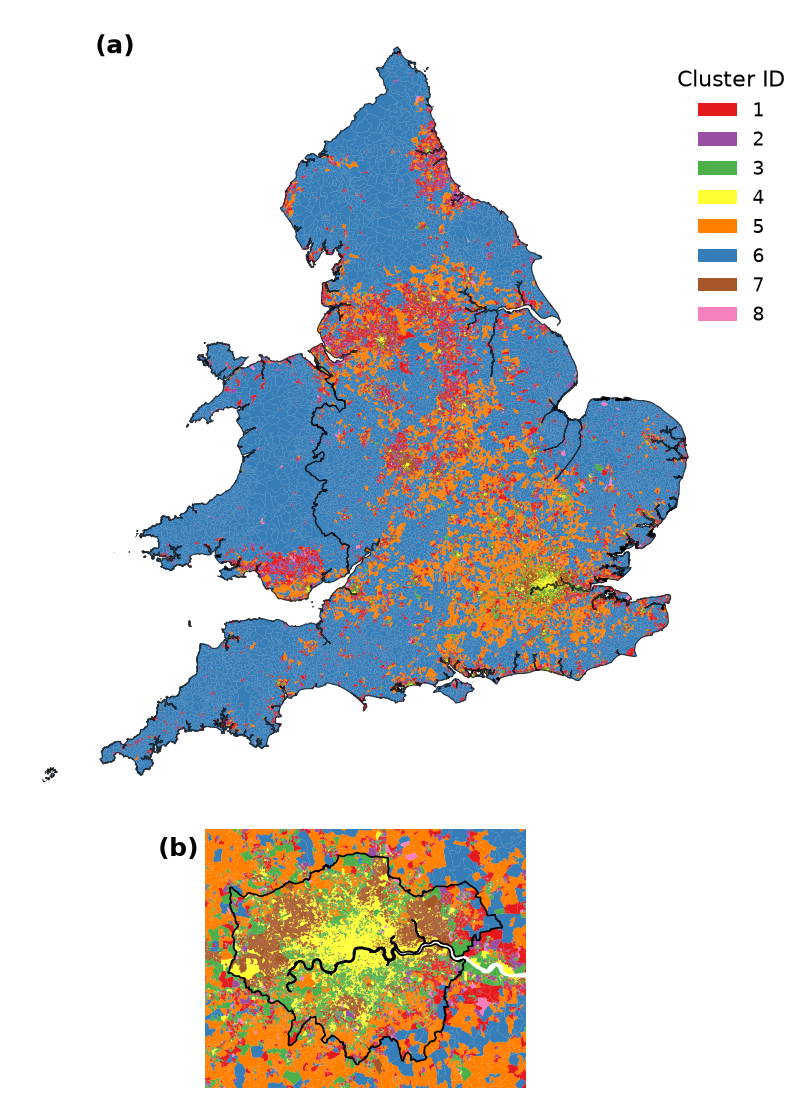

Saved: ./plots/pub_plots//publication_map_ae_100d_original.png

Rendering Set1_perm03...


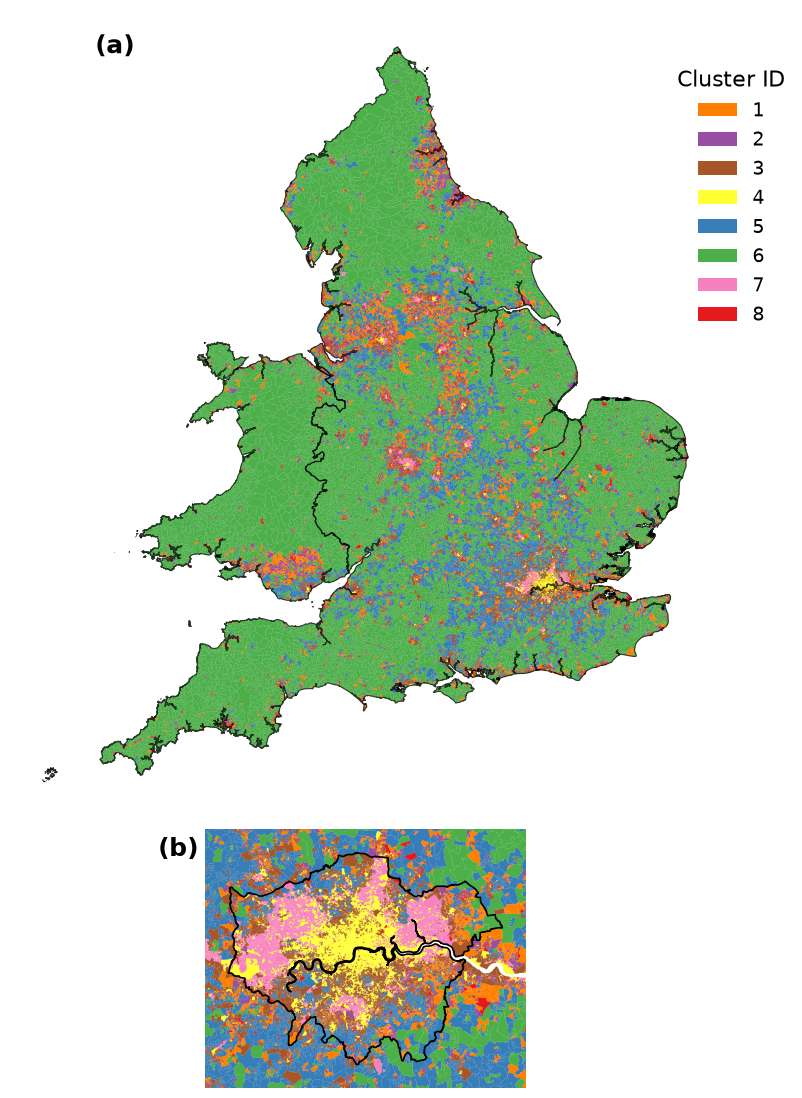

Saved: ./plots/pub_plots//publication_map_ae_100d_Set1_perm03.png


In [9]:

# London bounds
minx, miny, maxx, maxy = london_boundary.total_bounds
buffer = 5000
london_bounds = {
    'minx': minx - buffer, 'maxx': maxx + buffer,
    'miny': miny - buffer, 'maxy': maxy + buffer
}
gdf_london = gdf.cx[london_bounds['minx']:london_bounds['maxx'],
                     london_bounds['miny']:london_bounds['maxy']]

for pal_name, cluster_colors in palettes_to_plot.items():
    print(f"\nRendering {pal_name}...")
    color_list = [cluster_colors[i] for i in range(1, n_clusters + 1)]
    cmap = ListedColormap(color_list)
    bounds = np.arange(0.5, n_clusters + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    fig, axes = plt.subplots(2, 1, figsize=(10, 14),
                             gridspec_kw={'height_ratios': [2.5, 0.8],
                                          'hspace': 0.02})
    ax_uk, ax_ldn = axes

    # UK map
    gdf.plot(column='ae_cluster', ax=ax_uk, cmap=cmap, norm=norm,
             linewidth=0.1, edgecolor='face', legend=False)
    eng_wales_gdf.boundary.plot(ax=ax_uk, linewidth=0.8, edgecolor='black', alpha=0.7)
    ax_uk.text(0.12, 0.97, '(a)', transform=ax_uk.transAxes,
               fontsize=18, fontweight='bold', va='top', ha='left')
    ax_uk.axis('off')

    # London map — unclipped, with boundary overlay
    gdf_london.plot(column='ae_cluster', ax=ax_ldn, cmap=cmap, norm=norm,
                    linewidth=0.1, edgecolor='face', legend=False)
    london_boundary.boundary.plot(ax=ax_ldn, linewidth=1.2, edgecolor='black')
    ax_ldn.set_xlim(london_bounds['minx'], london_bounds['maxx'])
    ax_ldn.set_ylim(london_bounds['miny'], london_bounds['maxy'])
    ax_ldn.set_aspect('equal')
    ax_ldn.text(-0.02, 0.97, '(b)', transform=ax_ldn.transAxes,
                fontsize=18, fontweight='bold', va='top', ha='right')
    ax_ldn.axis('off')

    for ax in [ax_uk, ax_ldn]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')

    legend_elements = [Patch(facecolor=cluster_colors[i], label=str(i))
                       for i in range(1, n_clusters + 1)]
    fig.legend(handles=legend_elements, loc='upper right', ncol=1,
               fontsize=14, frameon=False, title='Cluster ID', title_fontsize=16,
               bbox_to_anchor=(0.95, 0.85))

    plt.tight_layout()
    save_path = f"{output_dir}/publication_map_ae_{target_dim}d_{pal_name}.png"
    plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    #transparent for presentation, but white for publication
    plt.savefig(save_path.replace('.png', '_transparent.png'), dpi=600, bbox_inches='tight', facecolor='none', edgecolor='none')
    plt.show()
    print(f"Saved: {save_path}")


Creating publication-quality AE cluster vs OAC overlap visualisation...



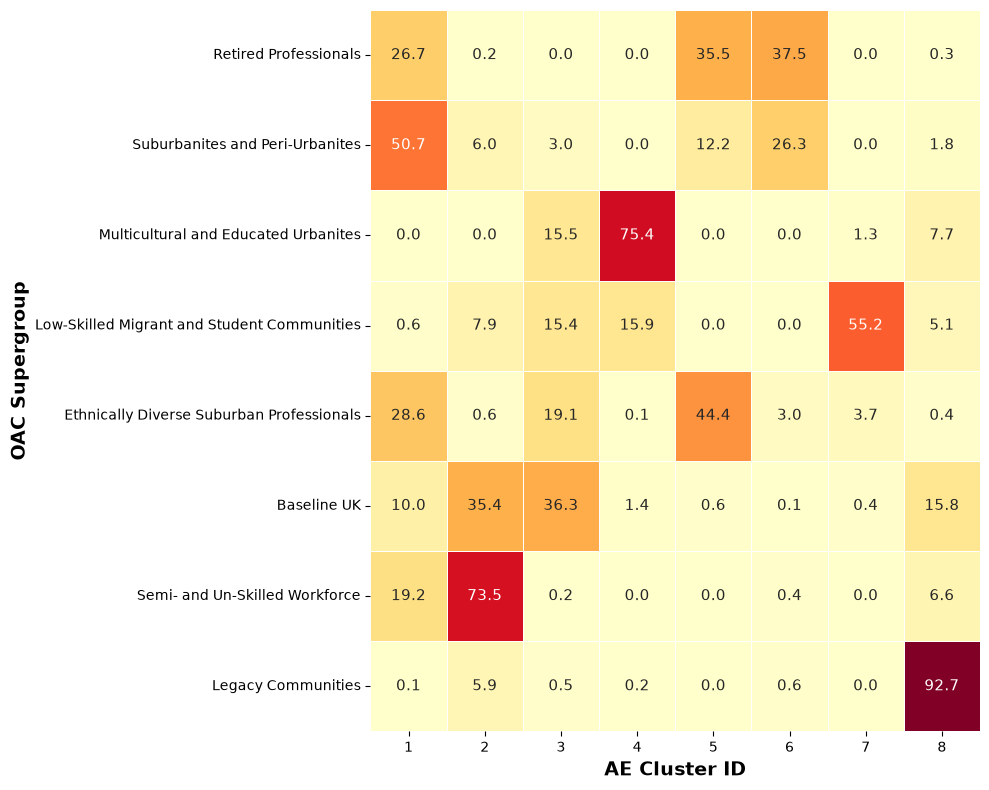

Saved heatmap to ./plots/pub_plots//ae_oac_overlap_publication_100d.png
Saved transparent: ./plots/pub_plots//ae_oac_overlap_publication_100d_transparent.png and .pdf


In [10]:
# Publication-quality AE cluster vs OAC overlap analysis
print("Creating publication-quality AE cluster vs OAC overlap visualisation...\n")

# OAC Supergroup names
oac_names = {
    1: "Retired Professionals",
    2: "Suburbanites and Peri-Urbanites",
    3: "Multicultural and Educated Urbanites",
    4: "Low-Skilled Migrant and Student Communities",
    5: "Ethnically Diverse Suburban Professionals",
    6: "Baseline UK",
    7: "Semi- and Un-Skilled Workforce",
    8: "Legacy Communities"
}

# Recompute overlap for AE only with nice labels
def cluster_oac_overlap_named(cluster_labels, oac_labels, oac_names):
    """Return count and percentage matrices with named OAC labels."""
    valid_mask = ~pd.isna(oac_labels)
    oac_valid = oac_labels[valid_mask]
    clusters_valid = cluster_labels[valid_mask] # Fix: add 1 to convert 0-indexed to 1-indexed
    
    oac_ids = list(range(1, n_clusters + 1))
    cluster_ids = list(range(1, n_clusters + 1))
    
    counts = pd.crosstab(oac_valid, clusters_valid)
    counts = counts.reindex(index=oac_ids, columns=cluster_ids, fill_value=0)
    
    # Rename index to OAC names
    counts.index = [oac_names[i] for i in counts.index]
    counts.columns = [str(i) for i in counts.columns]
    
    # Row-wise percentages: for each OAC, what % falls into each AE cluster
    percentages = counts.divide(counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
    percentages = percentages.fillna(0)
    
    return counts, percentages

ae_counts_named, ae_percent_named = cluster_oac_overlap_named(
    clusters_df['ae_cluster'].values, oac['Supergroup8'].values, oac_names
)

# === Publication Heatmap (OAC as rows, AE Cluster as columns) ===
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(ae_percent_named, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, cbar=False,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11})

ax.set_xlabel('AE Cluster ID', fontsize=14, fontweight='bold')
ax.set_ylabel('OAC Supergroup', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)

plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f"{output_dir}/ae_oac_overlap_publication_{target_dim}d.png", 
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig(f"{output_dir}/ae_oac_overlap_publication_{target_dim}d.jpeg", 
            dpi=600, bbox_inches='tight', facecolor='white')
# Transparent versions
plt.savefig(f"{output_dir}/ae_oac_overlap_publication_{target_dim}d_transparent.png", 
            dpi=600, bbox_inches='tight', transparent=True)
plt.savefig(f"{output_dir}/ae_oac_overlap_publication_{target_dim}d_transparent.pdf", 
            bbox_inches='tight', transparent=True)
plt.show()

print(f"Saved heatmap to {output_dir}/ae_oac_overlap_publication_{target_dim}d.png")
print(f"Saved transparent: {output_dir}/ae_oac_overlap_publication_{target_dim}d_transparent.png and .pdf")

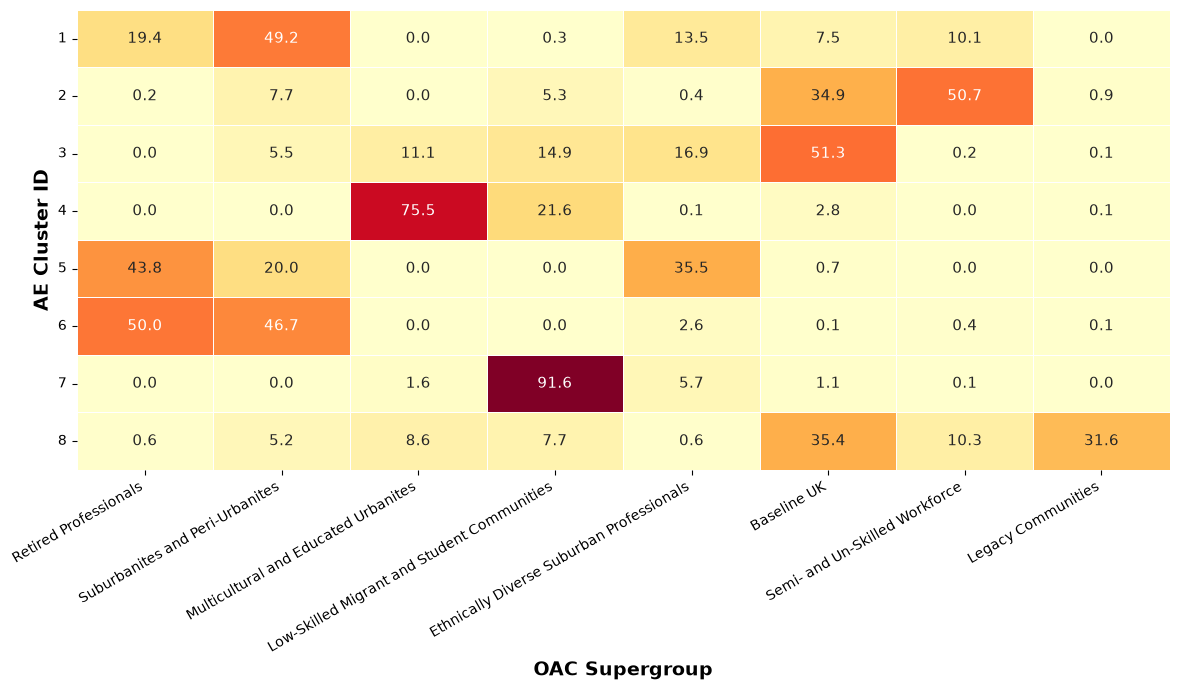

Saved transpose to ./plots/pub_plots//ae_oac_overlap_transpose_100d.png


In [11]:
# === Transposed version: AE Cluster as rows, OAC as columns ===
# Column-normalised on the original: each AE cluster sums to 100%
# Answers: "given an OA is in this AE cluster, what % came from each OAC?"
ae_percent_colnorm = ae_counts_named.divide(
    ae_counts_named.sum(axis=0).replace(0, np.nan), axis=1
) * 100
ae_percent_colnorm = ae_percent_colnorm.fillna(0).T  # transpose so AE clusters are rows

fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(ae_percent_colnorm, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, cbar=False,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11})

ax.set_xlabel('OAC Supergroup', fontsize=14, fontweight='bold')
ax.set_ylabel('AE Cluster ID', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f"{output_dir}/ae_oac_overlap_transpose_{target_dim}d.png",
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig(f"{output_dir}/ae_oac_overlap_transpose_{target_dim}d.jpeg",
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig(f"{output_dir}/ae_oac_overlap_transpose_{target_dim}d_transparent.png",
            dpi=600, bbox_inches='tight', transparent=True)
plt.savefig(f"{output_dir}/ae_oac_overlap_transpose_{target_dim}d_transparent.pdf",
            bbox_inches='tight', transparent=True)
plt.show()

print(f"Saved transpose to {output_dir}/ae_oac_overlap_transpose_{target_dim}d.png")

## AE vs PCA: same clustering, or different maps?

Reviewer request: alongside the AE clustering map (Figure 6), produce a **comparable PCA
clustering map** and **identify the areas classified differently** by the two
dimensionality-reduction methods, with a view to the **policy implications** — where the
choice of AE vs PCA changes an area's classification, resources/interventions keyed to that
classification would be targeted differently.

Direction: PCA is the conventional baseline, so we frame the comparison **PCA → AE** — starting
from the standard PCA classification, where does the AE relocate areas.

This section:
1. **Aligns** PCA cluster labels to the AE label frame (Hungarian matching) so the two are directly comparable, and reports the % of OAs classified identically + the Adjusted Rand Index.
2. **Transition matrix** (PCA → AE) heatmap — the reclassification table.
3. **Sankey** of PCA → AE flows built from that table.
4. **PCA publication map** matching the AE Figure 6 style.
5. **Disagreement map** showing where the two methods place an OA in different clusters, plus the largest PCA → AE reclassification flows for the policy discussion.

In [12]:
# Align PCA cluster labels to the AE label frame.
# KMeans cluster IDs are arbitrary, so before we can ask "where do the two methods
# disagree?" PCA labels must be put on the SAME frame as AE. We use optimal (Hungarian)
# matching on the AE x PCA contingency table, which maximises the on-diagonal agreement.
# NOTE: the AE labels here are the manually-remapped frame from the `mapping_ae` cell
# above (NOT the OAC-aligned frame), so we align PCA -> AE directly rather than reusing
# the OAC remap files.
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score

ae_labels = clusters_df['ae_cluster'].astype(int)   # 1..8 (AE frame)
pca_raw   = clusters_df['pca_cluster'].astype(int)  # 0..7 (raw KMeans)

cont = pd.crosstab(pca_raw, ae_labels).reindex(columns=range(1, n_clusters + 1), fill_value=0)
row_ind, col_ind = linear_sum_assignment(-cont.values)  # maximise overlap
pca_to_ae = {int(cont.index[r]): int(cont.columns[c]) for r, c in zip(row_ind, col_ind)}
assert len(set(pca_to_ae.values())) == n_clusters, "alignment is not a bijection"

print("PCA raw -> AE-frame label mapping (Hungarian):")
for k in sorted(pca_to_ae):
    print(f"  PCA {k}  ->  {pca_to_ae[k]}")

clusters_df['pca_cluster_aligned'] = pca_raw.map(pca_to_ae)

# Agreement metrics
agree = clusters_df['ae_cluster'] == clusters_df['pca_cluster_aligned']
pct_agree = agree.mean() * 100
ari = adjusted_rand_score(clusters_df['ae_cluster'], clusters_df['pca_cluster'])  # label-invariant
print(f"\nOAs classified identically by AE and PCA: {agree.sum():,} / {len(agree):,} ({pct_agree:.1f}%)")
print(f"OAs classified differently:               {(~agree).sum():,} ({100 - pct_agree:.1f}%)")
print(f"Adjusted Rand Index (AE vs PCA):          {ari:.4f}")

# Push aligned + agreement columns onto the geodataframe (index = OA) and rebuild the
# London slice so the new columns are visible in it.
gdf['pca_cluster_aligned'] = clusters_df['pca_cluster_aligned']
gdf['agreement'] = agree.astype(int)   # 1 = agree, 0 = disagree
gdf_london = gdf.cx[london_bounds['minx']:london_bounds['maxx'],
                    london_bounds['miny']:london_bounds['maxy']]

PCA raw -> AE-frame label mapping (Hungarian):
  PCA 0  ->  5
  PCA 1  ->  7
  PCA 2  ->  3
  PCA 3  ->  8
  PCA 4  ->  6
  PCA 5  ->  1
  PCA 6  ->  2
  PCA 7  ->  4

OAs classified identically by AE and PCA: 159,152 / 188,880 (84.3%)
OAs classified differently:               29,728 (15.7%)
Adjusted Rand Index (AE vs PCA):          0.6815


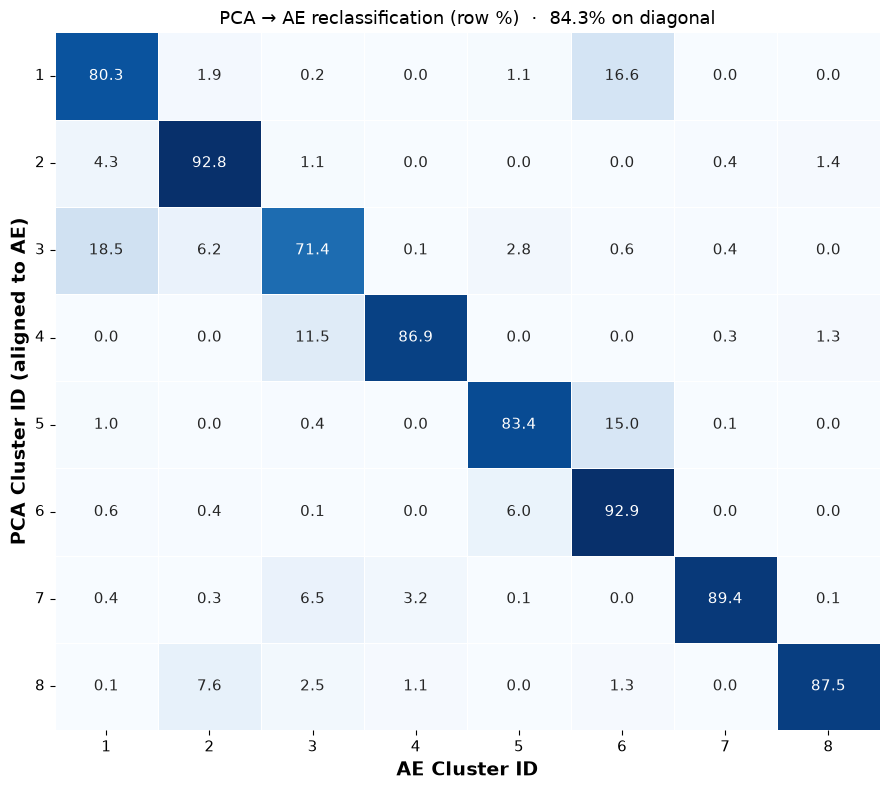

Saved transition heatmap to ./plots/pub_plots//pca_ae_transition_100d.png


In [13]:
# Transition matrix: rows = PCA cluster (aligned to AE), cols = AE cluster.
# Row-normalised: "of the OAs PCA assigns to cluster i, what % does the AE place in each
# cluster?" i.e. starting from the conventional PCA classification, where does the AE move
# areas. The diagonal is agreement; off-diagonal cells are reclassifications. This is the
# data behind the Sankey below.
trans = pd.crosstab(clusters_df['pca_cluster_aligned'], clusters_df['ae_cluster'])
trans = trans.reindex(index=range(1, n_clusters + 1),
                      columns=range(1, n_clusters + 1), fill_value=0)
trans_pct = trans.divide(trans.sum(axis=1).replace(0, np.nan), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(trans_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax, cbar=False,
            linewidths=0.5, linecolor='white', annot_kws={'size': 11})
ax.set_xlabel('AE Cluster ID', fontsize=14, fontweight='bold')
ax.set_ylabel('PCA Cluster ID (aligned to AE)', fontsize=14, fontweight='bold')
ax.set_title(f'PCA → AE reclassification (row %)  ·  {pct_agree:.1f}% on diagonal',
             fontsize=13)
ax.tick_params(axis='both', labelsize=11)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/pca_ae_transition_{target_dim}d.png", dpi=600,
            bbox_inches='tight', facecolor='white')
plt.savefig(f"{output_dir}/pca_ae_transition_{target_dim}d.pdf",
            bbox_inches='tight', transparent=True)
plt.show()
print(f"Saved transition heatmap to {output_dir}/pca_ae_transition_{target_dim}d.png")

In [14]:
# Sankey diagram: PCA clusters (left) -> AE clusters (right).
# Flow width = number of OAs; diagonal flows (i -> i) are the OAs both methods agree on.
# `trans` has rows = PCA cluster, cols = AE cluster (see cell above).
import plotly.graph_objects as go

pal = palettes_to_plot['Set1_perm03']  # cluster_id -> hex

node_labels = [f"PCA {i}" for i in range(1, n_clusters + 1)] + \
              [f"AE {i}" for i in range(1, n_clusters + 1)]
node_colors = [pal[i] for i in range(1, n_clusters + 1)] * 2

def _hex_to_rgba(h, a):
    h = h.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{a})"

sources, targets, values, link_colors = [], [], [], []
for i in range(1, n_clusters + 1):          # PCA cluster (source, left)
    for j in range(1, n_clusters + 1):      # AE cluster (target, right)
        v = int(trans.loc[i, j])
        if v == 0:
            continue
        sources.append(i - 1)
        targets.append(n_clusters + (j - 1))
        values.append(v)
        # colour by source (PCA) cluster; agreements (i==j) more opaque than reclassifications
        link_colors.append(_hex_to_rgba(pal[i], 0.65 if i == j else 0.28))

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(label=node_labels, color=node_colors, pad=15, thickness=18,
              line=dict(color='black', width=0.5)),
    link=dict(source=sources, target=targets, value=values, color=link_colors),
))
fig.update_layout(
    title_text=(f"PCA &#8594; AE cluster flows ({target_dim}D, k={n_clusters}) "
                f"&#8212; {pct_agree:.1f}% unchanged"),
    font=dict(size=13), width=900, height=700,
)

sankey_png = f"{output_dir}/pca_ae_sankey_{target_dim}d.png"
fig.write_html(f"{output_dir}/pca_ae_sankey_{target_dim}d.html")
try:
    fig.write_image(sankey_png, scale=2)  # static PNG needs kaleido + Chrome
    print(f"Saved Sankey to {sankey_png} and .html")
except Exception as e:
    print(f"Saved Sankey .html; static PNG export skipped ({type(e).__name__}: {e}).")
    print("  Run `plotly_get_chrome` in the venv to enable PNG export.")
fig.show()

Saved Sankey to ./plots/pub_plots//pca_ae_sankey_100d.png and .html


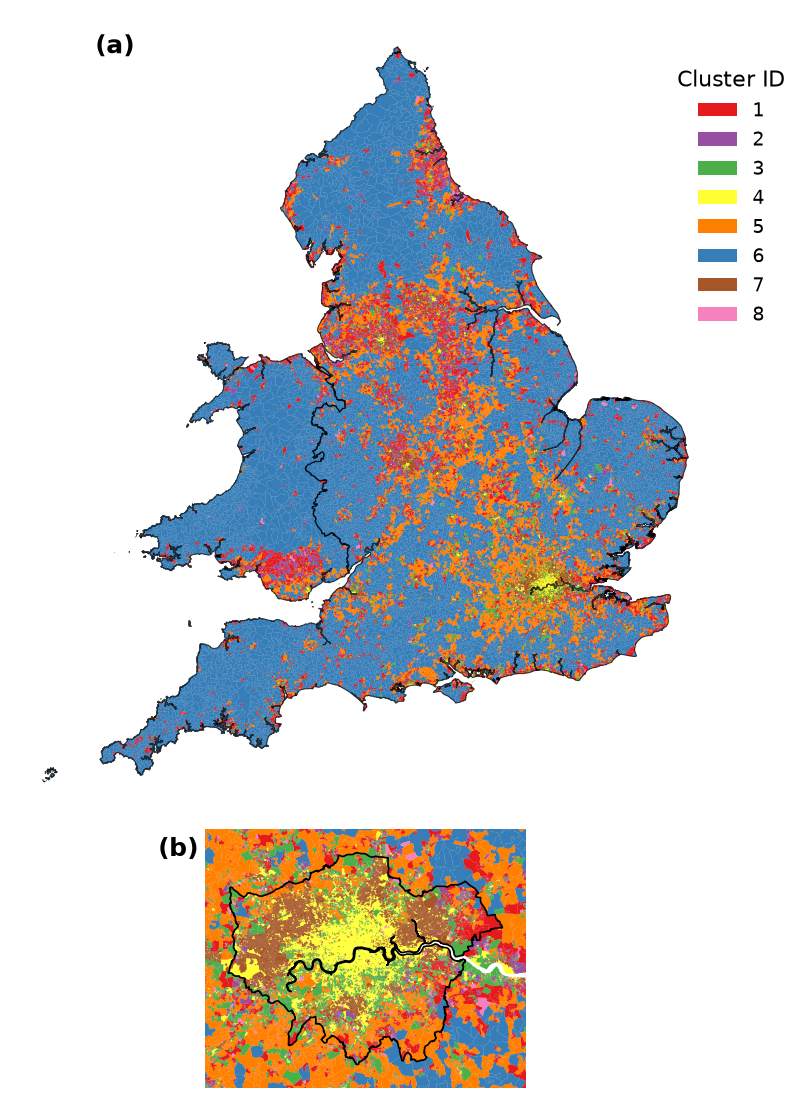

Saved: ./plots/pub_plots//publication_map_pca_100d_original.png


In [15]:
# Publication PCA cluster map — mirrors the AE Figure 6 layout/style so the two
# are directly comparable. Uses the published Figure 6 palette and the AE-aligned PCA
# labels, so identical colours = "the same geodemographic group".
cluster_colors = palettes_to_plot['Set1_perm03']
color_list = [cluster_colors[i] for i in range(1, n_clusters + 1)]
cmap = ListedColormap(color_list)
bounds = np.arange(0.5, n_clusters + 1.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(2, 1, figsize=(10, 14),
                         gridspec_kw={'height_ratios': [2.5, 0.8], 'hspace': 0.02})
ax_uk, ax_ldn = axes

gdf.plot(column='pca_cluster_aligned', ax=ax_uk, cmap=cmap, norm=norm,
         linewidth=0.1, edgecolor='face', legend=False)
eng_wales_gdf.boundary.plot(ax=ax_uk, linewidth=0.8, edgecolor='black', alpha=0.7)
ax_uk.text(0.12, 0.97, '(a)', transform=ax_uk.transAxes, fontsize=18,
           fontweight='bold', va='top', ha='left')
ax_uk.axis('off')

gdf_london.plot(column='pca_cluster_aligned', ax=ax_ldn, cmap=cmap, norm=norm,
                linewidth=0.1, edgecolor='face', legend=False)
london_boundary.boundary.plot(ax=ax_ldn, linewidth=1.2, edgecolor='black')
ax_ldn.set_xlim(london_bounds['minx'], london_bounds['maxx'])
ax_ldn.set_ylim(london_bounds['miny'], london_bounds['maxy'])
ax_ldn.set_aspect('equal')
ax_ldn.text(-0.02, 0.97, '(b)', transform=ax_ldn.transAxes, fontsize=18,
            fontweight='bold', va='top', ha='right')
ax_ldn.axis('off')

for ax in [ax_uk, ax_ldn]:
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(1.5); spine.set_edgecolor('black')

legend_elements = [Patch(facecolor=cluster_colors[i], label=str(i))
                   for i in range(1, n_clusters + 1)]
fig.legend(handles=legend_elements, loc='upper right', ncol=1, fontsize=14,
           frameon=False, title='Cluster ID', title_fontsize=16,
           bbox_to_anchor=(0.95, 0.85))

plt.tight_layout()
save_path = f"{output_dir}/publication_map_pca_{target_dim}d_original.png"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(save_path.replace('.png', '_transparent.png'), dpi=600,
            bbox_inches='tight', facecolor='none', edgecolor='none')
plt.show()
print(f"Saved: {save_path}")

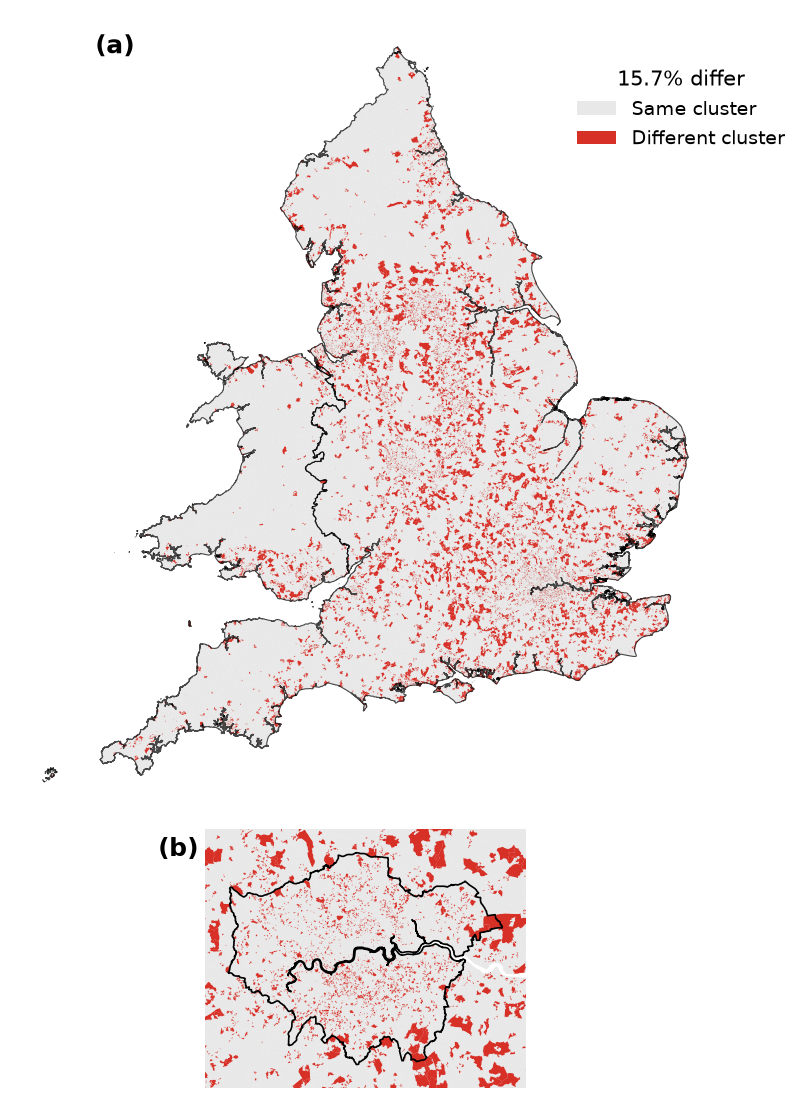

Saved: ./plots/pub_plots//ae_pca_disagreement_map_100d.png

Largest PCA -> AE reclassification flows (off-diagonal):
  PCA 1 -> AE 6: 7,398 OAs (16.6% of PCA cluster 1)
  PCA 3 -> AE 1: 4,844 OAs (18.5% of PCA cluster 3)
  PCA 5 -> AE 6: 4,139 OAs (15.0% of PCA cluster 5)
  PCA 4 -> AE 3: 2,033 OAs (11.5% of PCA cluster 4)
  PCA 3 -> AE 2: 1,622 OAs (6.2% of PCA cluster 3)
  PCA 2 -> AE 1: 1,331 OAs (4.3% of PCA cluster 2)
  PCA 8 -> AE 2: 1,181 OAs (7.6% of PCA cluster 8)
  PCA 7 -> AE 3: 925 OAs (6.5% of PCA cluster 7)
  PCA 1 -> AE 2: 865 OAs (1.9% of PCA cluster 1)
  PCA 3 -> AE 5: 731 OAs (2.8% of PCA cluster 3)


In [16]:
# Disagreement map: where do PCA and AE place an OA in DIFFERENT clusters?
# (uses the AE-aligned PCA labels, so a difference is a genuine reclassification)
disagree_color = '#d73027'   # red
agree_color    = '#e8e8e8'   # light grey
dis_cmap = ListedColormap([agree_color, disagree_color])
dis_norm = BoundaryNorm([-0.5, 0.5, 1.5], dis_cmap.N)

gdf['disagree'] = 1 - gdf['agreement']
gdf_london = gdf.cx[london_bounds['minx']:london_bounds['maxx'],
                    london_bounds['miny']:london_bounds['maxy']]

fig, axes = plt.subplots(2, 1, figsize=(10, 14),
                         gridspec_kw={'height_ratios': [2.5, 0.8], 'hspace': 0.02})
ax_uk, ax_ldn = axes

gdf.plot(column='disagree', ax=ax_uk, cmap=dis_cmap, norm=dis_norm,
         linewidth=0.1, edgecolor='face', legend=False)
eng_wales_gdf.boundary.plot(ax=ax_uk, linewidth=0.8, edgecolor='black', alpha=0.7)
ax_uk.text(0.12, 0.97, '(a)', transform=ax_uk.transAxes, fontsize=18,
           fontweight='bold', va='top', ha='left')
ax_uk.axis('off')

gdf_london.plot(column='disagree', ax=ax_ldn, cmap=dis_cmap, norm=dis_norm,
                linewidth=0.1, edgecolor='face', legend=False)
london_boundary.boundary.plot(ax=ax_ldn, linewidth=1.2, edgecolor='black')
ax_ldn.set_xlim(london_bounds['minx'], london_bounds['maxx'])
ax_ldn.set_ylim(london_bounds['miny'], london_bounds['maxy'])
ax_ldn.set_aspect('equal')
ax_ldn.text(-0.02, 0.97, '(b)', transform=ax_ldn.transAxes, fontsize=18,
            fontweight='bold', va='top', ha='right')
ax_ldn.axis('off')

for ax in [ax_uk, ax_ldn]:
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(1.5); spine.set_edgecolor('black')

legend_elements = [Patch(facecolor=agree_color, label='Same cluster'),
                   Patch(facecolor=disagree_color, label='Different cluster')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=14, frameon=False,
           title=f'{100 - pct_agree:.1f}% differ', title_fontsize=15,
           bbox_to_anchor=(0.95, 0.85))

plt.tight_layout()
save_path = f"{output_dir}/ae_pca_disagreement_map_{target_dim}d.png"
plt.savefig(save_path, dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(save_path.replace('.png', '_transparent.png'), dpi=600,
            bbox_inches='tight', facecolor='none', edgecolor='none')
plt.show()
print(f"Saved: {save_path}")

# Largest reclassification flows (off-diagonal) to anchor the policy discussion.
# `trans` rows = PCA cluster, cols = AE cluster: PCA i -> AE j.
print("\nLargest PCA -> AE reclassification flows (off-diagonal):")
off = [(i, j, int(trans.loc[i, j]), trans_pct.loc[i, j])
       for i in range(1, n_clusters + 1) for j in range(1, n_clusters + 1)
       if i != j and trans.loc[i, j] > 0]
for i, j, cnt, pctv in sorted(off, key=lambda x: -x[2])[:10]:
    print(f"  PCA {i} -> AE {j}: {cnt:,} OAs ({pctv:.1f}% of PCA cluster {i})")